# Visualize SCPMNet TPS images

Use this notebook to inspect synthetic TPS image arrays, detection overlays, and TPS `z_surface` maps generated by `src.det.SCPMNet.generate_luna16_tps_images`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

OUTPUT_ROOT = Path("outputs/scpmnet_luna16_10fold_tps_images")
FOLD = 0
MANIFEST = OUTPUT_ROOT / f"fold_{FOLD}" / "manifest.csv"

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 120

print("manifest:", MANIFEST)
print("exists:", MANIFEST.exists())

manifest: outputs/scpmnet_luna16_10fold_tps_images/fold_0/manifest.csv
exists: True


In [2]:
df = pd.read_csv(MANIFEST)

for col in ["synthetic_image", "overlay_image", "z_surface"]:
    df[f"{col}_exists"] = df[col].fillna("").map(lambda p: Path(str(p)).exists())

print("rows:", len(df))
print("folds:", sorted(df["fold"].unique().tolist()))
print("anchor grids:", sorted(df["anchor_grid_size"].dropna().unique().tolist()) if "anchor_grid_size" in df else "missing")
print("clip margins:", sorted(df["surface_clip_margin"].dropna().unique().tolist()) if "surface_clip_margin" in df else "missing")
print()
print(df[["synthetic_image_exists", "overlay_image_exists", "z_surface_exists"]].sum())

df.head(3)

rows: 89
folds: [0]
anchor grids: [10]
clip margins: [40.0]

synthetic_image_exists    89
overlay_image_exists      89
z_surface_exists          89
dtype: int64


,fold,seriesuid,image_path,prediction_csv,synthetic_image,overlay_image,z_surface,num_detections,anchor_grid_size,surface_clip_margin,top_probability,mean_detection_z,min_detection_z,max_detection_z,synthetic_image_exists,overlay_image_exists,z_surface_exists
0,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260,/ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260...,outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.105756658031515062000744821260_tps...,5,10,40.0,0.592296,155.116362,99.195160,196.937607,True,True,True
1,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492,/ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492...,outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492_tps...,5,10,40.0,0.774101,106.614358,35.817020,266.185577,True,True,True
2,0,1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059,/ssd2/domenico/datasets/LUNA16_preprocessed/subset0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059...,outputs/scpmnet_luna16_10fold/scpmnet_paper_luna16_fold0/predictions/test_predictions.csv,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059_tps...,outputs/scpmnet_luna16_10fold_tps_images/fold_0/1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059_tps...,5,10,40.0,0.558641,120.650804,70.993828,166.137131,True,True,True


In [3]:
def load_array(path):
    return np.load(Path(path))


def load_overlay(path):
    return np.asarray(Image.open(Path(path)).convert("RGB"))


def top_detections_for_row(row):
    pred = pd.read_csv(row["prediction_csv"])
    pred["seriesuid"] = pred["seriesuid"].astype(str)
    det = pred[pred["seriesuid"] == str(row["seriesuid"])].copy()
    det = det.sort_values("probability", ascending=False).head(int(row.get("num_detections", 5)))
    return det.reset_index(drop=True)


def robust_limits(image, low=1, high=99):
    lo, hi = np.percentile(image[np.isfinite(image)], [low, high])
    if hi <= lo:
        lo, hi = float(np.nanmin(image)), float(np.nanmax(image))
    return lo, hi


def surface_stats(surface):
    gy, gx = np.gradient(surface)
    return {
        "z_min": float(surface.min()),
        "z_max": float(surface.max()),
        "z_mean": float(surface.mean()),
        "z_std": float(surface.std()),
        "mean_abs_grad_y": float(np.abs(gy).mean()),
        "mean_abs_grad_x": float(np.abs(gx).mean()),
    }


def row_by_index_or_series(index=0, seriesuid=None):
    if seriesuid is not None:
        hits = df[df["seriesuid"].astype(str) == str(seriesuid)]
        if hits.empty:
            raise ValueError(f"seriesuid not found: {seriesuid}")
        return hits.iloc[0]
    return df.iloc[int(index)]

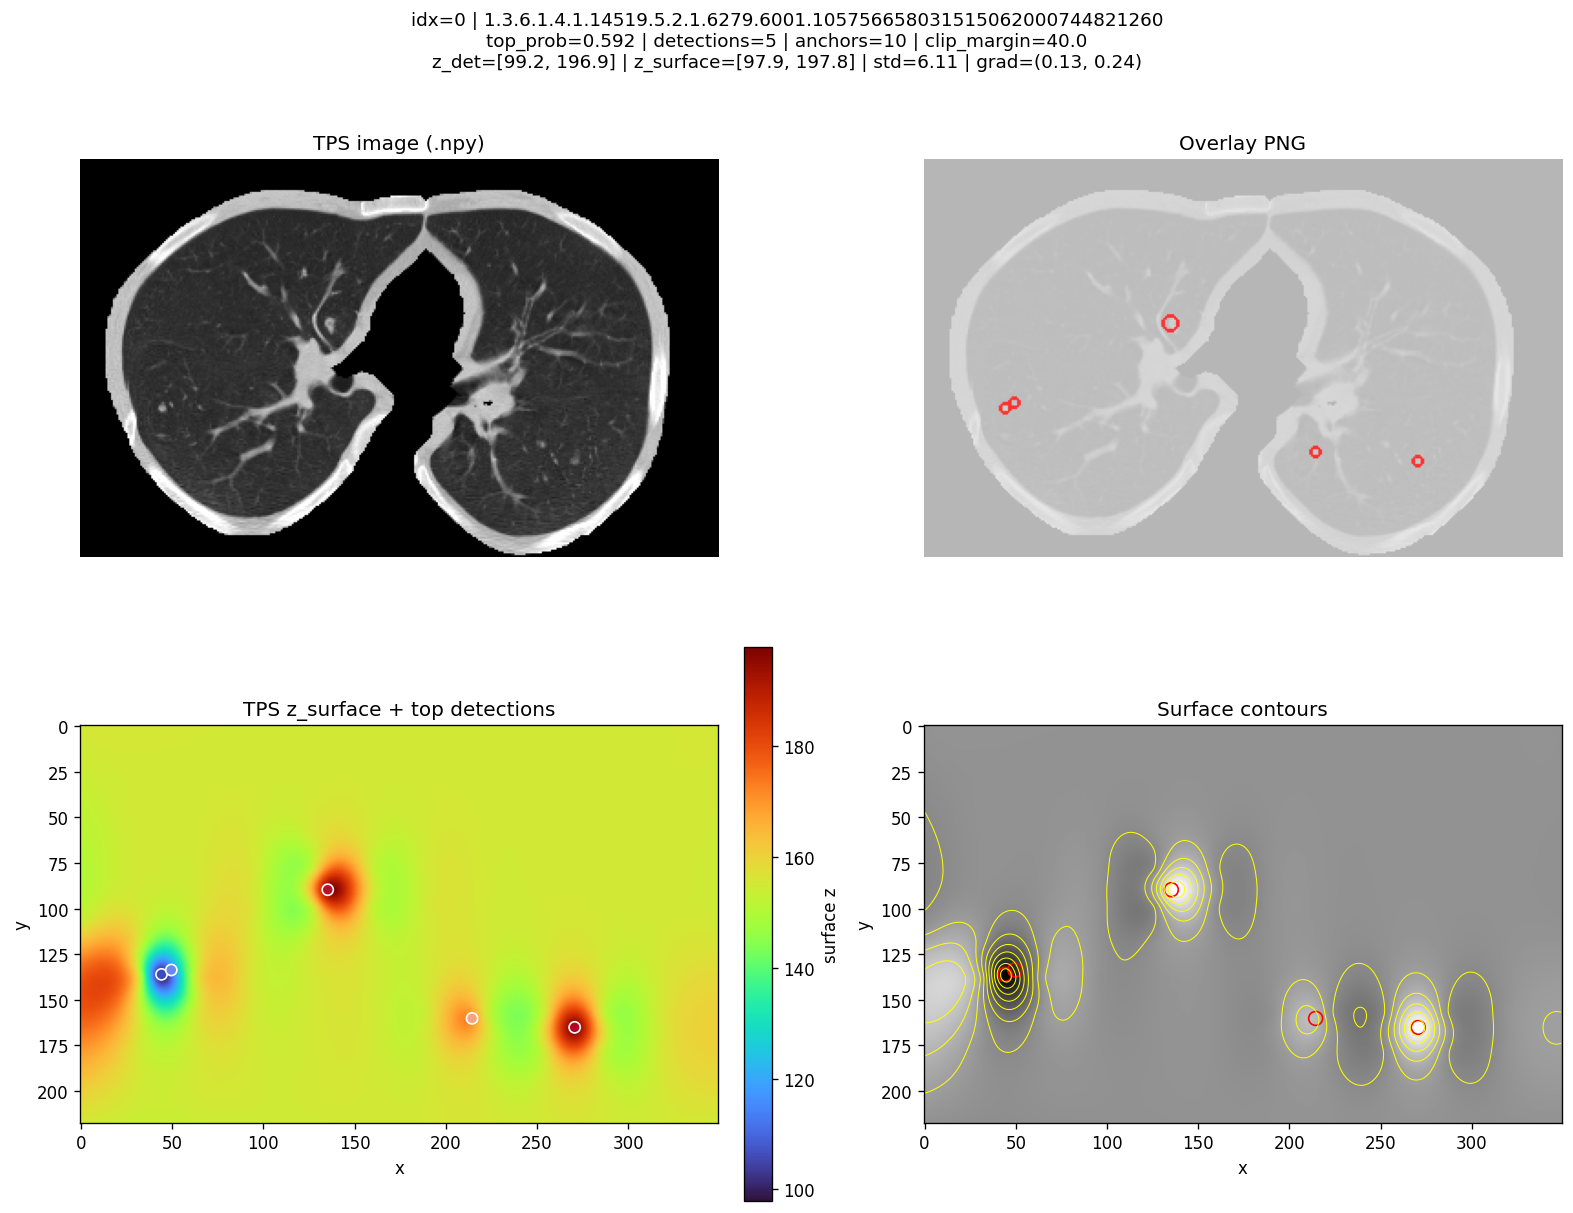

,coordZ,coordY,coordX,radius,probability
0,99.195160,136.101593,44.143169,3.019821,0.592296
1,113.447044,133.693466,49.505596,2.440850,0.495757
2,196.937607,165.146820,270.683350,2.653441,0.488892
3,195.690506,89.689339,135.290833,4.388144,0.473830
4,170.311493,160.244217,214.417892,2.635722,0.453470


In [4]:
def show_case(index=0, seriesuid=None, image_percentiles=(1, 99), surface_contours=12):
    row = row_by_index_or_series(index=index, seriesuid=seriesuid)
    image = load_array(row["synthetic_image"])
    overlay = load_overlay(row["overlay_image"]) if Path(str(row["overlay_image"])).exists() else None
    surface = load_array(row["z_surface"])
    detections = top_detections_for_row(row)
    stats = surface_stats(surface)

    lo, hi = robust_limits(image, *image_percentiles)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

    axes[0, 0].imshow(image, cmap="gray", vmin=lo, vmax=hi)
    axes[0, 0].set_title("TPS image (.npy)")
    axes[0, 0].axis("off")

    if overlay is not None:
        axes[0, 1].imshow(overlay)
        axes[0, 1].set_title("Overlay PNG")
    else:
        axes[0, 1].imshow(image, cmap="gray", vmin=lo, vmax=hi)
        axes[0, 1].set_title("Overlay missing")
    axes[0, 1].axis("off")

    surf_im = axes[1, 0].imshow(surface, cmap="turbo")
    axes[1, 0].scatter(detections["coordX"], detections["coordY"], c=detections["coordZ"], cmap="coolwarm", edgecolor="white", s=45)
    axes[1, 0].set_title("TPS z_surface + top detections")
    axes[1, 0].set_xlabel("x")
    axes[1, 0].set_ylabel("y")
    plt.colorbar(surf_im, ax=axes[1, 0], fraction=0.046, pad=0.04, label="surface z")

    axes[1, 1].imshow(surface, cmap="gray")
    axes[1, 1].contour(surface, levels=surface_contours, colors="yellow", linewidths=0.6)
    axes[1, 1].scatter(detections["coordX"], detections["coordY"], facecolors="none", edgecolors="red", s=70)
    axes[1, 1].set_title("Surface contours")
    axes[1, 1].set_xlabel("x")
    axes[1, 1].set_ylabel("y")

    title = (
        f"idx={df.index[df['seriesuid'].astype(str) == str(row['seriesuid'])][0]} | {row['seriesuid']}\n"
        f"top_prob={row['top_probability']:.3f} | detections={int(row['num_detections'])} | "
        f"anchors={row.get('anchor_grid_size', 'NA')} | clip_margin={row.get('surface_clip_margin', 'NA')}\n"
        f"z_det=[{row.get('min_detection_z', np.nan):.1f}, {row.get('max_detection_z', np.nan):.1f}] | "
        f"z_surface=[{stats['z_min']:.1f}, {stats['z_max']:.1f}] | std={stats['z_std']:.2f} | "
        f"grad=({stats['mean_abs_grad_y']:.2f}, {stats['mean_abs_grad_x']:.2f})"
    )
    fig.suptitle(title, fontsize=11)
    plt.show()

    display(detections[["coordZ", "coordY", "coordX", "radius", "probability"]])
    return row, stats


_ = show_case(index=0)

In [5]:
# Optional interactive browser. If ipywidgets is unavailable, use show_case(index=...) manually.
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    slider = widgets.IntSlider(value=0, min=0, max=len(df) - 1, step=1, description="index", continuous_update=False)
    out = widgets.Output()

    def on_change(change=None):
        with out:
            clear_output(wait=True)
            show_case(index=slider.value)

    slider.observe(on_change, names="value")
    display(slider, out)
    on_change()
except Exception as exc:
    print("Interactive widgets unavailable:", exc)
    print("Use show_case(index=10) or show_case(seriesuid='...') instead.")

IntSlider(value=0, continuous_update=False, description='index', max=88)

Output()

In [6]:
def add_surface_quality_columns(frame):
    rows = []
    for idx, row in frame.iterrows():
        surface = load_array(row["z_surface"])
        stats = surface_stats(surface)
        clip_margin = row.get("surface_clip_margin", np.nan)
        det_min = row.get("min_detection_z", np.nan)
        det_max = row.get("max_detection_z", np.nan)
        if pd.notna(clip_margin) and pd.notna(det_min) and pd.notna(det_max):
            lo = max(float(det_min) - float(clip_margin), 0.0)
            hi = float(det_max) + float(clip_margin)
            stats["clip_low_frac"] = float(np.isclose(surface, lo, atol=1e-3).mean())
            stats["clip_high_frac"] = float(np.isclose(surface, hi, atol=1e-3).mean())
        else:
            stats["clip_low_frac"] = np.nan
            stats["clip_high_frac"] = np.nan
        rows.append({"index": idx, "seriesuid": row["seriesuid"], **stats})
    return pd.DataFrame(rows).merge(frame, on="seriesuid", how="left")


quality = add_surface_quality_columns(df)
quality.sort_values("z_std", ascending=False).head(12)[[
    "index", "seriesuid", "z_min", "z_max", "z_mean", "z_std", "mean_abs_grad_y", "mean_abs_grad_x", "clip_low_frac", "clip_high_frac"
]]

,index,seriesuid,z_min,z_max,z_mean,z_std,mean_abs_grad_y,mean_abs_grad_x,clip_low_frac,clip_high_frac
53,53,1.3.6.1.4.1.14519.5.2.1.6279.6001.311981398931043315779172047718,80.741585,309.621063,200.323685,26.308983,0.376500,0.729071,0.010256,0.024079
45,45,1.3.6.1.4.1.14519.5.2.1.6279.6001.294188507421106424248264912111,19.110191,279.743011,154.175476,19.142378,0.559274,0.876568,0.002380,0.000000
68,68,1.3.6.1.4.1.14519.5.2.1.6279.6001.450501966058662668272378865145,5.891018,282.238129,192.452087,18.123238,0.290397,0.566252,0.001060,0.001590
71,71,1.3.6.1.4.1.14519.5.2.1.6279.6001.534006575256943390479252771547,57.476093,264.663177,181.017532,14.814260,0.245916,0.364581,0.000000,0.000000
51,51,1.3.6.1.4.1.14519.5.2.1.6279.6001.310548927038333190233889983845,12.184407,246.000000,150.255417,14.688249,0.400246,0.628825,0.000000,0.000000
67,67,1.3.6.1.4.1.14519.5.2.1.6279.6001.430109407146633213496148200410,38.742371,305.000000,179.040436,14.259203,0.433608,0.439774,0.000123,0.000000
20,20,1.3.6.1.4.1.14519.5.2.1.6279.6001.187451715205085403623595258748,31.936218,279.416077,157.257828,13.841803,0.480762,0.599113,0.000000,0.000000
79,79,1.3.6.1.4.1.14519.5.2.1.6279.6001.724251104254976962355686318345,0.000000,224.593018,69.428986,13.729758,0.358772,0.489341,0.003461,0.001429
43,43,1.3.6.1.4.1.14519.5.2.1.6279.6001.281489753704424911132261151767,6.948269,191.935059,110.975952,13.418783,0.380601,0.509388,0.000000,0.000000
1,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492,30.850630,270.038208,107.579605,13.115860,0.335262,0.529389,0.000000,0.000000


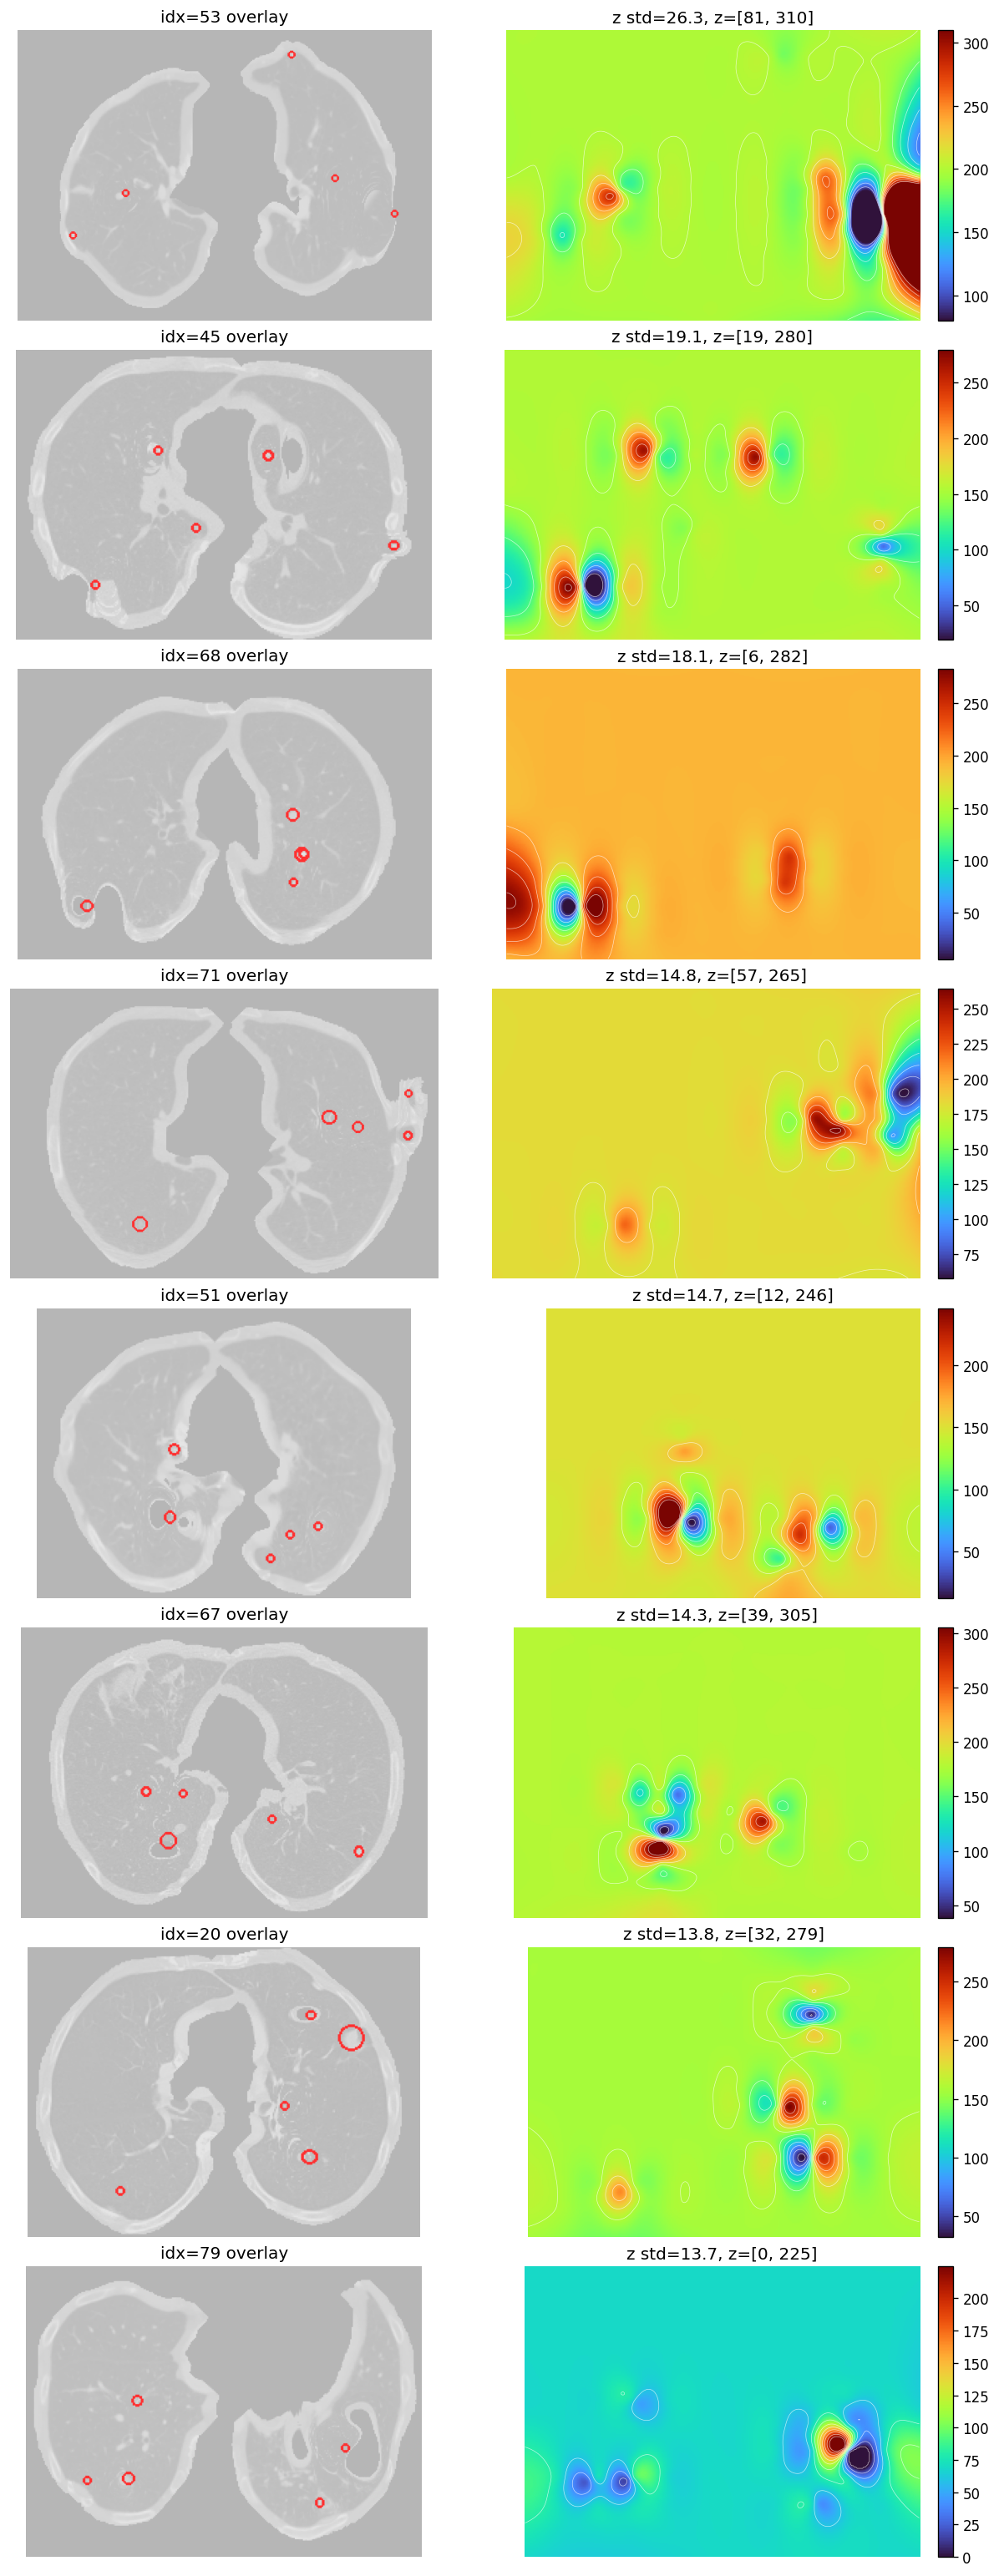

In [7]:
def show_worst_surfaces(n=12, sort_by="z_std"):
    rows = quality.sort_values(sort_by, ascending=False).head(n)
    cols = 3
    fig, axes = plt.subplots(len(rows), 2, figsize=(10, 3.2 * len(rows)), constrained_layout=True)
    if len(rows) == 1:
        axes = np.asarray([axes])
    for ax_pair, (_, row) in zip(axes, rows.iterrows()):
        image = load_array(row["synthetic_image"])
        overlay = load_overlay(row["overlay_image"])
        surface = load_array(row["z_surface"])
        ax_pair[0].imshow(overlay)
        ax_pair[0].set_title(f"idx={int(row['index'])} overlay")
        ax_pair[0].axis("off")
        im = ax_pair[1].imshow(surface, cmap="turbo")
        ax_pair[1].contour(surface, levels=12, colors="white", linewidths=0.4, alpha=0.7)
        ax_pair[1].set_title(f"z std={row['z_std']:.1f}, z=[{row['z_min']:.0f}, {row['z_max']:.0f}]")
        ax_pair[1].axis("off")
        plt.colorbar(im, ax=ax_pair[1], fraction=0.046, pad=0.04)
    plt.show()


show_worst_surfaces(n=8, sort_by="z_std")

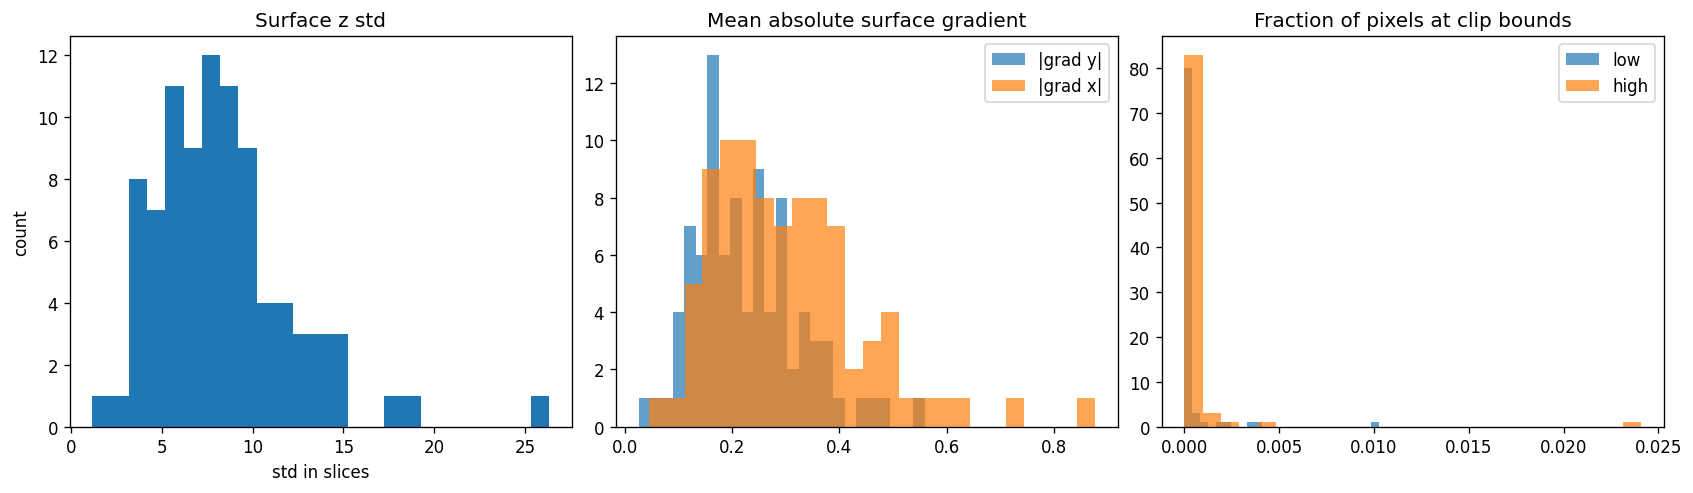

,z_std,mean_abs_grad_y,mean_abs_grad_x,clip_low_frac,clip_high_frac
count,89.000000,89.000000,89.000000,89.000000,89.000000
mean,8.339311,0.227224,0.305728,0.000288,0.000392
std,3.870773,0.099415,0.141822,0.001250,0.002597
min,1.176144,0.025042,0.044370,0.000000,0.000000
25%,5.813126,0.156149,0.201499,0.000000,0.000000
50%,7.684256,0.208792,0.279161,0.000000,0.000000
75%,9.804163,0.290397,0.376457,0.000000,0.000000
max,26.308983,0.559274,0.876568,0.010256,0.024079


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
axes[0].hist(quality["z_std"], bins=25)
axes[0].set_title("Surface z std")
axes[0].set_xlabel("std in slices")
axes[0].set_ylabel("count")

axes[1].hist(quality["mean_abs_grad_y"], bins=25, alpha=0.7, label="|grad y|")
axes[1].hist(quality["mean_abs_grad_x"], bins=25, alpha=0.7, label="|grad x|")
axes[1].set_title("Mean absolute surface gradient")
axes[1].legend()

axes[2].hist(quality["clip_low_frac"].fillna(0), bins=25, alpha=0.7, label="low")
axes[2].hist(quality["clip_high_frac"].fillna(0), bins=25, alpha=0.7, label="high")
axes[2].set_title("Fraction of pixels at clip bounds")
axes[2].legend()
plt.show()

quality[["z_std", "mean_abs_grad_y", "mean_abs_grad_x", "clip_low_frac", "clip_high_frac"]].describe()